# How to compute required input

```
# in case you want to resort the BAM file
samtools sort -@ 7 P_6_2_J_1.sorted.bam -o P_6_2_J_1.resorted.bam --write-index
```

### Starting from a BAM file you can run this 
```
samtools view IA010_C_1_H_1.sorted.bam | awk 'BEGIN{OFS="\t"} !/^@/ { if ($8 < $4) { print $1, $3, $8, $4    } else {        print $1,  $3, $4, $8    }}' | sort | uniq | cut -f 2- | sort | uniq -c | sort -nr | gzip > IA010_C_1_H_1.sorted.read_counts_custom.tsv.gz
```

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
sample = "IA010_C_1_H_1"
run = "/data/bbg/nobackup2/prominent/colon_duplex/iarc_pilot/deepUMI/2025-10-27_NOV69-70_plus_all_colon_DU5_set1"

In [3]:
# sample = "IA011_C_1_H_2"
# run = "/data/bbg/nobackup2/prominent/colon_duplex/iarc_pilot/deepUMI/2025-11-01_NOV70_colon_redo_only_new_samples_DU7"
sample = "C_11_2_H_1"
run = "/data/bbg/nobackup2/prominent/colon_duplex/iarc_pilot/deepUMI/2025-09-04_deepUMI_NOV66_colon"

In [16]:
sample = "P_6_2_J_1"
run = "/data/bbg/nobackup/prominent/pancreas/2025-10-28_pilot_samples"

In [41]:
sample = [
#             "TS_DNA_TS_FEZ_TS_Adapters_idt_v2",
#             "TS_DNA_IDT_EZF",
#             "TS_DNA_75uM_IDT_idt_v3_speedvac",
            "Cord_Blood_3_Ultrashear",
            # "Cord_Blood_3_IDT_EZF_FPGUDG_338",
            # "Cord_Blood_3_IDT_EZF_354",
            "Cord_Blood_3_bufferR1_1",
            # "Cord_Blood_3_3uM_KapaPCR",
            # "Cord_Blood_3_3uM_IDTPCR",
            # "Cord_Blood_3_15uM_KapaPCR",
        ]
sample = "Cord_Blood_3_bufferR1_1"
# sample = "Cord_Blood_3_Ultrashear"
run = "/data/bbg/nobackup2/prominent/duplex_seq_tests/technology_tests/rosana_data/2025-11-03.tests/2025-11-04_deepUMIcaller"

## All molecules

In [17]:
data = pd.read_csv(f"{run}/sortbamamfiltered/{sample}.sorted.read_counts_custom.tsv.gz",
                   sep="\s+",
                   header=None)

In [18]:
data.columns = ["count", "CHROM", "START", "END"]
data.head(20)

,count,CHROM,START,END
0,2807,chr17,7676342,7676342
1,1203,chr2,211678967,211678967
2,985,chr2,211428467,211428467
3,905,chr2,212124843,212124843
4,892,chr2,211428423,211428423
5,891,chr20,58910349,58910349
6,849,chr2,211722440,211722440
7,807,chr2,211420443,211420443
8,782,chr2,211722398,211722398
9,781,chr2,211665386,211665386


In [19]:
# define a predefined set of bins to ensure consistency across samples, the last bin should include anything bigger than that
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 400, 500, 600, 1e6]


In [20]:
# use the previously defined bins to categorize the data
data['binned_count'] = pd.cut(data['count'], bins=bins, right=False)
# data['probability'] = data['binned_count'].value_counts(normalize=True)

In [21]:
count_data = data['binned_count'].value_counts(normalize=True).sort_index().reset_index()
count_data.columns = ['binned_count', 'probability']
count_data

,binned_count,probability
0,"[0.0, 5.0)",0.975814
1,"[5.0, 10.0)",0.017078
2,"[10.0, 15.0)",0.001538
3,"[15.0, 20.0)",0.000511
4,"[20.0, 25.0)",0.000347
5,"[25.0, 30.0)",0.000297
6,"[30.0, 35.0)",0.000277
7,"[35.0, 40.0)",0.000273
8,"[40.0, 45.0)",0.000240
9,"[45.0, 50.0)",0.000237


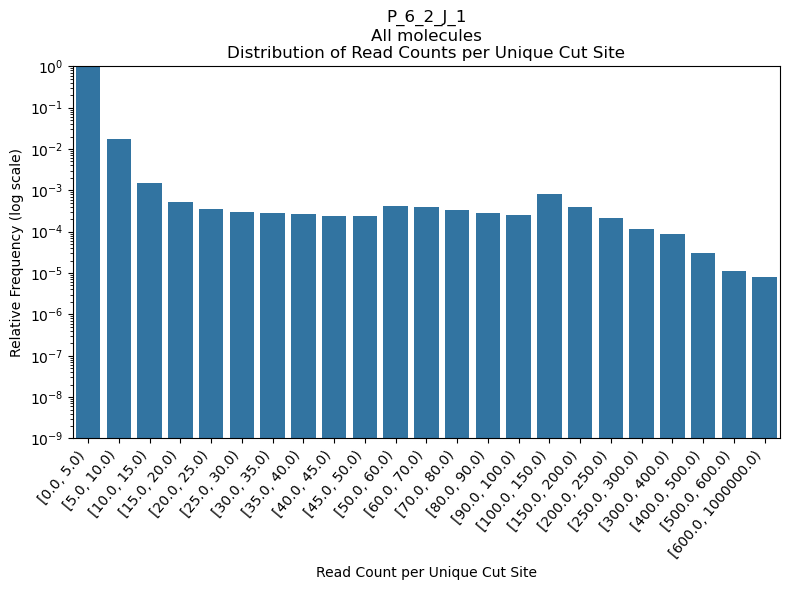

In [22]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=count_data,
    x="binned_count",
    y="probability"
)
plt.yscale("log")
plt.xticks(rotation=50, ha='right')
plt.xlabel("Read Count per Unique Cut Site")
plt.ylabel("Relative Frequency (log scale)")
plt.title(f"{sample}\nAll molecules\nDistribution of Read Counts per Unique Cut Site")
plt.ylim(1e-9, 1)
plt.tight_layout()
plt.show()


## Duplex molecules

In [23]:
data_duplex = pd.read_csv(f"{run}/sortbamduplexcons/{sample}.sorted.read_counts_custom.tsv.gz",
                   sep="\s+",
                   header=None)
data_duplex.columns = ["count", "CHROM", "START", "END"]

In [24]:
data_duplex.head()

,count,CHROM,START,END
0,101,chr17,7676342,7676390
1,75,chr17,7676342,7676421
2,75,chr17,7676342,7676381
3,73,chr17,7676342,7676379
4,64,chr17,7676342,7676391


In [25]:
# use the previously defined bins to categorize the data
data_duplex['binned_count'] = pd.cut(data_duplex['count'], bins=bins, right=False)

count_data_duplex = data_duplex['binned_count'].value_counts(normalize=True).sort_index().reset_index()
count_data_duplex.columns = ['binned_count', 'probability']
count_data_duplex

,binned_count,probability
0,"[0.0, 5.0)",9.685655e-01
1,"[5.0, 10.0)",2.857819e-02
2,"[10.0, 15.0)",2.339908e-03
3,"[15.0, 20.0)",3.697098e-04
4,"[20.0, 25.0)",8.798078e-05
5,"[25.0, 30.0)",3.303249e-05
6,"[30.0, 35.0)",1.111670e-05
7,"[35.0, 40.0)",4.764302e-06
8,"[40.0, 45.0)",2.858581e-06
9,"[45.0, 50.0)",1.905721e-06


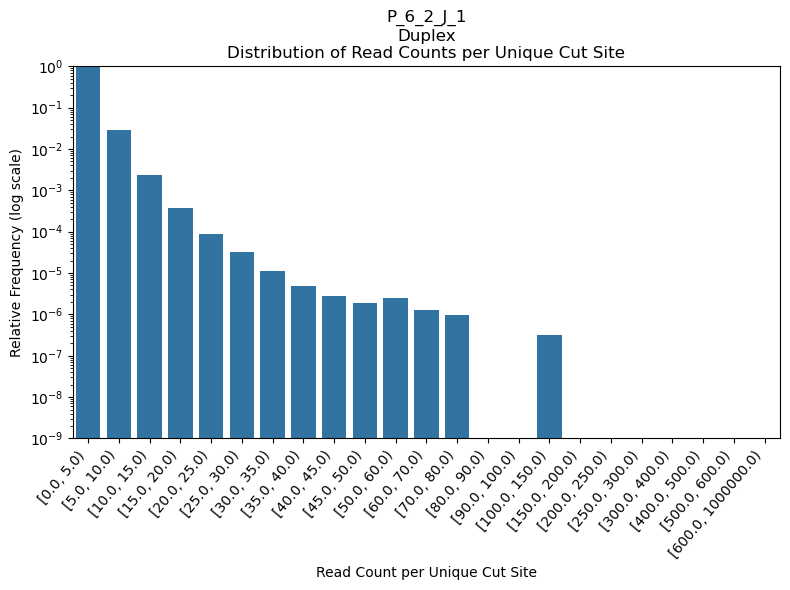

In [26]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=count_data_duplex,
    x="binned_count",
    y="probability"
)
plt.yscale("log")
plt.xticks(rotation=50, ha='right')
plt.xlabel("Read Count per Unique Cut Site")
plt.ylabel("Relative Frequency (log scale)")
plt.title(f"{sample}\nDuplex\nDistribution of Read Counts per Unique Cut Site")
plt.ylim(1e-9, 1)
plt.tight_layout()
plt.show()

## UMI counts

In [42]:
# umi_counts_data = pd.read_table(f"{run}/collectduplexseqmetricsontarget/{sample}_chr1.on_target.duplex_seq_metrics.umi_counts.txt")
umi_counts_data = pd.read_table(f"{run}/collectduplexseqmetricsontarget/{sample}.on_target.duplex_seq_metrics.umi_counts.txt")
umi_counts_data = umi_counts_data.sort_values("fraction_raw_observations", ascending = False).reset_index(drop=True)
umi_counts_data["cummulative_fraction"] = umi_counts_data["fraction_raw_observations"].cumsum()
umi_counts_data.head()

,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,cummulative_fraction
0,AAT,2938378,0,460782,0.026431,0.025781,0.026431
1,CCT,2623326,0,426328,0.023597,0.023853,0.050028
2,ATA,2605815,0,411504,0.023440,0.023024,0.073468
3,TTA,2550628,0,396723,0.022943,0.022197,0.096411
4,TTT,2520883,0,393887,0.022676,0.022038,0.119087


In [43]:
# major_freq = umi_counts_data[umi_counts_data["cummulative_fraction"] <= 0.99]
# minor_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] > 0.99].sum()

major_freq_df = umi_counts_data.iloc[:100,:]
minor_freq_df = umi_counts_data.iloc[100:,:]
minor_freq = minor_freq_df.sum()
minor_freq["umi"] = str(len(minor_freq_df)) + 'umis'
minor_freq["cummulative_fraction"] = 1
minor_freq

umi                             0umis
raw_observations                    0
raw_observations_with_errors        0
unique_observations                 0
fraction_raw_observations         0.0
fraction_unique_observations      0.0
cummulative_fraction                1
dtype: object

In [44]:
merged_umis = pd.concat([major_freq_df, minor_freq.to_frame().T], ignore_index=True)
merged_umis = merged_umis.reset_index()
merged_umis.head()

,index,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,cummulative_fraction
0,0,AAT,2938378,0,460782,0.026431,0.025781,0.026431
1,1,CCT,2623326,0,426328,0.023597,0.023853,0.050028
2,2,ATA,2605815,0,411504,0.02344,0.023024,0.073468
3,3,TTA,2550628,0,396723,0.022943,0.022197,0.096411
4,4,TTT,2520883,0,393887,0.022676,0.022038,0.119087


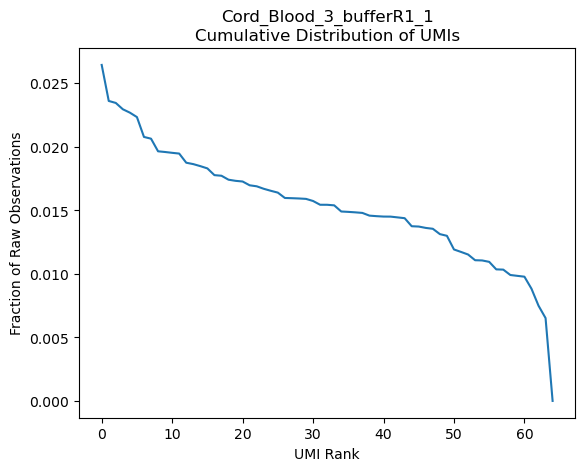

In [45]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.lineplot(data=merged_umis, x="index", y="fraction_raw_observations")
plt.xlabel("UMI Rank")
plt.ylabel("Fraction of Raw Observations")
plt.title(f"{sample}\nCumulative Distribution of UMIs")
plt.show()

## Duplex UMI counts

In [44]:
# umi_counts_data = pd.read_table(f"{run}/collectduplexseqmetricsontarget/{sample}_chr1.on_target.duplex_seq_metrics.umi_counts.txt")
umi_counts_data = pd.read_table(f"{run}/collectduplexseqmetricsontarget/{sample}.on_target.duplex_seq_metrics.duplex_umi_counts.txt")
umi_counts_data = umi_counts_data.sort_values("fraction_raw_observations", ascending = False).reset_index(drop=True)
umi_counts_data["cummulative_fraction"] = umi_counts_data["fraction_raw_observations"].cumsum()
umi_counts_data.head()

,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,fraction_unique_observations_expected,cummulative_fraction
0,AAGACCTT-AGAGTCCT,55434,1258,4574,0.000442,0.000410,0.000407,0.000442
1,AGAGTCCT-GCACATCC,55094,1227,4370,0.000439,0.000392,0.000384,0.000881
2,AGAGTCCT-AAGACCTT,54465,1194,4579,0.000434,0.000410,0.000407,0.001315
3,AAGACCTT-GCACATCC,54291,1336,4343,0.000433,0.000389,0.000380,0.001748
4,GCACATCC-AGAGTCCT,53381,1273,4336,0.000426,0.000388,0.000384,0.002174


In [45]:
for threshold in [0.95, 0.99, 0.995, 0.999]:
    major_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] <= threshold]
    minor_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] > threshold]
    print(f"Threshold: {threshold}: major: {len(major_freq_df)}, minor: {len(minor_freq_df)}")
    print()


major_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] <= 0.999]
minor_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] > 0.999]
# major_freq_df = umi_counts_data.iloc[:100000,:]
# minor_freq_df = umi_counts_data.iloc[100000:,:]

print(len(major_freq_df), len(minor_freq_df))

minor_freq = minor_freq_df[['raw_observations', 'raw_observations_with_errors',
                            'unique_observations', 'fraction_raw_observations',
                            'fraction_unique_observations', 'fraction_unique_observations_expected',]].sum()
minor_freq["umi"] = str(len(minor_freq_df)) + ' umis'
minor_freq["cummulative_fraction"] = 1
minor_freq

Threshold: 0.95: major: 7772, minor: 387041

Threshold: 0.99: major: 9102, minor: 385711

Threshold: 0.995: major: 33938, minor: 360875

Threshold: 0.999: major: 269747, minor: 125066

269747 125066


raw_observations                            125066.0
raw_observations_with_errors                     0.0
unique_observations                         125066.0
fraction_raw_observations                   0.000997
fraction_unique_observations                0.011205
fraction_unique_observations_expected       0.003728
umi                                      125066 umis
cummulative_fraction                               1
dtype: object

In [33]:
merged_umis = pd.concat([major_freq_df, minor_freq.to_frame().T], ignore_index=True)
merged_umis = merged_umis.reset_index()
merged_umis.head()

,index,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,fraction_unique_observations_expected,cummulative_fraction
0,0,AAGACCTT-AGAGTCCT,55434,1258,4574,0.000442,0.00041,0.000407,0.000442
1,1,AGAGTCCT-GCACATCC,55094,1227,4370,0.000439,0.000392,0.000384,0.000881
2,2,AGAGTCCT-AAGACCTT,54465,1194,4579,0.000434,0.00041,0.000407,0.001315
3,3,AAGACCTT-GCACATCC,54291,1336,4343,0.000433,0.000389,0.00038,0.001748
4,4,GCACATCC-AGAGTCCT,53381,1273,4336,0.000426,0.000388,0.000384,0.002174


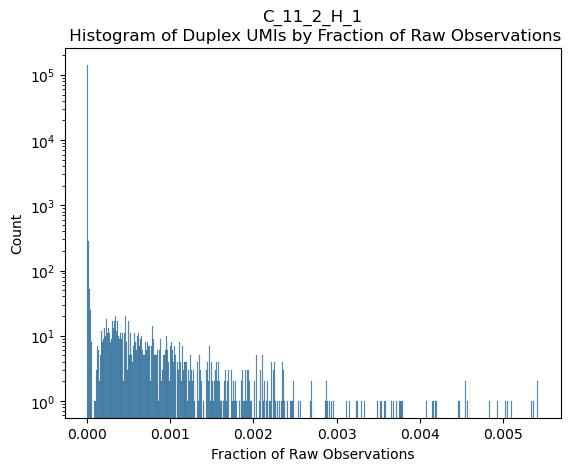

In [27]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.histplot(data=merged_umis, x="fraction_raw_observations", bins=500)
plt.xlabel("Fraction of Raw Observations")
plt.title(f"{sample}\n Histogram of Duplex UMIs by Fraction of Raw Observations")
# plt.xscale("log")
plt.yscale("log")
plt.show()

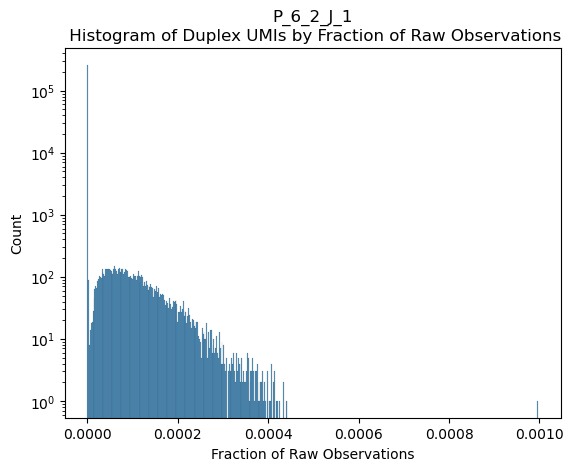

In [34]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.histplot(data=merged_umis, x="fraction_raw_observations", bins=500)

plt.xlabel("Fraction of Raw Observations")
plt.title(f"{sample}\n Histogram of Duplex UMIs by Fraction of Raw Observations")

plt.yscale("log")
plt.show()

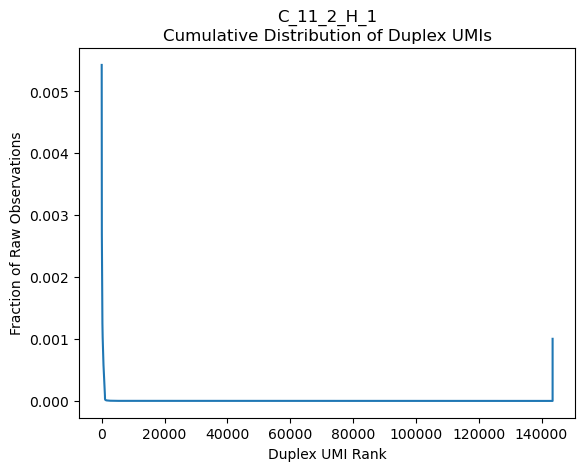

In [28]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.lineplot(data=merged_umis, x="index", y="fraction_raw_observations")
plt.xlabel("Duplex UMI Rank")
plt.ylabel("Fraction of Raw Observations")
plt.title(f"{sample}\nCumulative Distribution of Duplex UMIs")
plt.show()

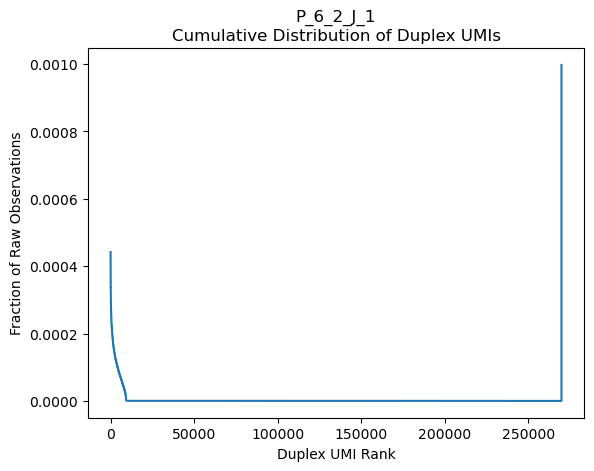

In [20]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.lineplot(data=merged_umis, x="index", y="fraction_raw_observations")
plt.xlabel("Duplex UMI Rank")
plt.ylabel("Fraction of Raw Observations")
plt.title(f"{sample}\nCumulative Distribution of Duplex UMIs")
plt.show()